In [3]:
from joblib import load, dump
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#from util import utils as ut
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier

import os
try:
    os.chdir("./aulas_teoricas")
except FileNotFoundError:
    pass


# Estruturação dos dados do projeto

In [4]:
import os

In [8]:
os.chdir("script" )
os.chdir("aulas_teoricas" )

In [9]:
os.listdir()



['00-divisão_dados_2026-07-14.ipynb',
 '01-aula-02_objetivos_2026-07-14.ipynb',
 '02-aula-04_aquisição_2026-07-14.ipynb',
 '03-aula-05_01-dados_2026-07-14.ipynb',
 '03-aula-05_02-cluster_2026-07-14.ipynb',
 '03-aula-05_03-classif_2026-07-14.ipynb',
 '03-aula-05_04-regressão_2026-07-14.ipynb',
 '03-aula-05_05_analise_2026-07-14.ipynb',
 '04-aula-06-divisão de dados_2026-07-14.ipynb',
 '05-aula-07-estruturação_2025-12-03.ipynb',
 '07-aula-09-01-treinamento_feat_selection_2026-07-26.ipynb',
 '07-aula-09-02-treinamento_cluster_2026-07-26.ipynb',
 '07-aula-09-03-treinamento_classif_2026-07-28.ipynb',
 '07-aula-09-04-treinamento_regressão_2026-07-28.ipynb',
 'data',
 'df_projeto_sem_nan',
 'SMOTE.ipynb',
 'src',
 'ydata-profiling.ipynb',
 '__init__.py']

# Importando dataframe de trabalho - 07-df-projeto


In [10]:
from joblib import dump, load

Carregamos a dataframe bruta do projeto 

In [11]:
# dump(df, "./data/07_aula_07_df_projeto")

df_projeto = load("./data/07_aula_07_df_projeto")
df_projeto.head()

,CD34,TdT,MPO,CD19_1,CD20_1,CD22,CD3_1,CD7,BCR-ABL,PML-RARA,...,IgA_2,IgM,CD16,CD56,DHR,CH50,C3,C4,FOXP3,classe
0,0.119362,True,True,0.471228,0.398837,0.233216,0.329756,0.417118,True,True,...,Alto,Alto,247.894093,396.067195,0.967908,93,230,42,Normal,leucemia
1,0.112420,True,True,0.292042,0.370941,0.253135,0.340733,0.350616,True,True,...,Alto,Alto,213.416161,361.036864,0.972741,135,351,64,Normal,leucemia
2,0.175636,True,True,0.372872,0.257518,0.451758,0.487803,0.399385,True,True,...,Alto,Alto,296.635039,244.867766,0.971384,69,238,44,Normal,leucemia
3,0.078518,True,True,0.469943,0.495637,0.351360,0.332752,0.487439,True,True,...,Alto,Alto,564.401375,530.296010,0.962450,90,262,41,Normal,leucemia
4,0.061083,True,True,0.349343,0.381742,0.220939,0.479723,0.453555,True,True,...,Alto,Alto,238.791009,152.442218,0.955740,76,209,46,Normal,leucemia


A buscar as informações da df usando _.info()_, fica claro que temos 38 colunas ao total, sendo que as colunas 11 - 14 e 16 parecem ter alguns erros (contagem diferente de 1000). Notamos também que os dados possuem diferentes formatos.

In [12]:
df_projeto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 38 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CD34      1000 non-null   float64
 1   TdT       1000 non-null   bool   
 2   MPO       1000 non-null   bool   
 3   CD19_1    1000 non-null   float64
 4   CD20_1    1000 non-null   float64
 5   CD22      1000 non-null   float64
 6   CD3_1     956 non-null    float64
 7   CD7       1000 non-null   float64
 8   BCR-ABL   1000 non-null   bool   
 9   PML-RARA  1000 non-null   bool   
 10  NMP22     1000 non-null   int64  
 11  BTA       965 non-null    object 
 12  hTERT     954 non-null    object 
 13  uCyt+     971 non-null    object 
 14  FGFR3     930 non-null    object 
 15  TP53      1000 non-null   float64
 16  PPD       916 non-null    float64
 17  IFN-γ     1000 non-null   float64
 18  IL-2      1000 non-null   object 
 19  TNF-α     1000 non-null   object 
 20  Th1       1000 non-null   int64

Neste momento, aplicamos o data profiling em um script do Google Colaboratory para evitar conflitos de versão das dependências

In [13]:
# Verificando valores faltantes  = CD3_1 com 44 e PPD com 84
df_projeto.isna().sum()

CD34         0
TdT          0
MPO          0
CD19_1       0
CD20_1       0
CD22         0
CD3_1       44
CD7          0
BCR-ABL      0
PML-RARA     0
NMP22        0
BTA         35
hTERT       46
uCyt+       29
FGFR3       70
TP53         0
PPD         84
IFN-γ        0
IL-2         0
TNF-α        0
Th1          0
IgG_1        0
IgA_1        0
CD3_2        0
CD4          0
CD8          0
CD19_2       0
CD20_2       0
IgA_2        0
IgM          0
CD16         0
CD56         0
DHR          0
CH50         0
C3           0
C4           0
FOXP3        0
classe       0
dtype: int64

Ao observar o relatório de pré-processamento, nota-se que ele indica 308 dados faltantes ao inves dos 44+84 indicados pelo isna()

In [14]:
import numpy as np

In [15]:
# Quantificando as entradas na variável CD3_1
df_projeto.CD3_1.value_counts().info()

<class 'pandas.core.series.Series'>
Index: 293 entries, 0.4576626258728855 to 0.1446090250395423
Series name: count
Non-Null Count  Dtype
--------------  -----
293 non-null    int64
dtypes: int64(1)
memory usage: 4.6 KB


Apesar de isna() relatar 44 NaNs nesta variavel, value_counts nao detecta a ausencia

In [16]:
df_projeto['CD3_1'].unique

<bound method Series.unique of 0      0.329756
1      0.340733
2      0.487803
3      0.332752
4      0.479723
         ...   
995    0.492897
996    0.184222
997    0.457663
998         NaN
999    0.134253
Name: CD3_1, Length: 1000, dtype: float64>

In [17]:
df_projeto['CD3_1'].dtype

dtype('float64')

Trocando eventuais NaN em string para NaN verdadeiro (numpy)

In [18]:
df_projeto.CD3_1 = df_projeto.CD3_1.replace("NaN", np.nan)


In [19]:
df_projeto.CD3_1.unique()

array([0.32975614, 0.34073307, 0.48780308, 0.33275179, 0.47972311,
       0.31482504, 0.31039059, 0.45405795, 0.31473674, 0.48867835,
       0.34617136, 0.37990772, 0.4429886 , 0.44294606, 0.33005125,
       0.41686913, 0.33887735, 0.42811693, 0.48838643, 0.41667878,
       0.39904932, 0.38790484, 0.35140992, 0.39515371, 0.43786653,
       0.41649522, 0.3195212 , 0.39098828, 0.45766263, 0.35525904,
       0.43164219, 0.43093005, 0.34372056, 0.44407768, 0.47956534,
       0.38885891, 0.47777583, 0.31021277, 0.3637659 , 0.47695168,
       0.3993165 , 0.43081233, 0.40959169, 0.46819387, 0.35803334,
       0.3163067 , 0.33731807, 0.3371146 , 0.42584018, 0.35211967,
       0.46477425, 0.33754159, 0.31467956, 0.44354687, 0.45641995,
       0.35327214, 0.48207228, 0.45953059, 0.47732136, 0.43836415,
       0.34873512, 0.40690369, 0.3771676 , 0.42735114, 0.32229965,
       0.3921511 , 0.384274  , 0.49834146, 0.46883704, 0.42337352,
       0.46190206, 0.46564059, 0.46905971, 0.36901044, 0.32028

Retirando o 'nan' que resta

In [20]:
df_projeto.CD3_1 = df_projeto.CD3_1.replace("nan", np.nan)

In [21]:
# Selecionando entradas com "nan" em CD3_1 -> não restaram nan string
df_projeto[df_projeto.CD3_1 == "nan"].head()

,CD34,TdT,MPO,CD19_1,CD20_1,CD22,CD3_1,CD7,BCR-ABL,PML-RARA,...,IgA_2,IgM,CD16,CD56,DHR,CH50,C3,C4,FOXP3,classe


Fazendo o mesmo para a variável PPD, que o relatório indicou com células missing

In [22]:
df_projeto.PPD = df_projeto.PPD.replace("nan", np.nan)
df_projeto.PPD = df_projeto.PPD.replace("NaN", np.nan)

In [23]:
# Veririfcando as informações da df
df_projeto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 38 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CD34      1000 non-null   float64
 1   TdT       1000 non-null   bool   
 2   MPO       1000 non-null   bool   
 3   CD19_1    1000 non-null   float64
 4   CD20_1    1000 non-null   float64
 5   CD22      1000 non-null   float64
 6   CD3_1     956 non-null    float64
 7   CD7       1000 non-null   float64
 8   BCR-ABL   1000 non-null   bool   
 9   PML-RARA  1000 non-null   bool   
 10  NMP22     1000 non-null   int64  
 11  BTA       965 non-null    object 
 12  hTERT     954 non-null    object 
 13  uCyt+     971 non-null    object 
 14  FGFR3     930 non-null    object 
 15  TP53      1000 non-null   float64
 16  PPD       916 non-null    float64
 17  IFN-γ     1000 non-null   float64
 18  IL-2      1000 non-null   object 
 19  TNF-α     1000 non-null   object 
 20  Th1       1000 non-null   int64

Agora faremos o preenchimento dos NaNs com a media dos dados das variáveis PPD e CD3_1

In [24]:
# Preenchendo valores faltantes com a mediana
df_projeto.PPD.fillna(np.mean(df_projeto.PPD.dropna()), inplace=True)
df_projeto.CD3_1.fillna(np.mean(df_projeto.CD3_1.dropna()), inplace=True)



C:\Users\sofia\AppData\Local\Temp\ipykernel_78900\1731186611.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_projeto.PPD.fillna(np.mean(df_projeto.PPD.dropna()), inplace=True)
C:\Users\sofia\AppData\Local\Temp\ipykernel_78900\1731186611.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [25]:
df_projeto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 38 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CD34      1000 non-null   float64
 1   TdT       1000 non-null   bool   
 2   MPO       1000 non-null   bool   
 3   CD19_1    1000 non-null   float64
 4   CD20_1    1000 non-null   float64
 5   CD22      1000 non-null   float64
 6   CD3_1     1000 non-null   float64
 7   CD7       1000 non-null   float64
 8   BCR-ABL   1000 non-null   bool   
 9   PML-RARA  1000 non-null   bool   
 10  NMP22     1000 non-null   int64  
 11  BTA       965 non-null    object 
 12  hTERT     954 non-null    object 
 13  uCyt+     971 non-null    object 
 14  FGFR3     930 non-null    object 
 15  TP53      1000 non-null   float64
 16  PPD       1000 non-null   float64
 17  IFN-γ     1000 non-null   float64
 18  IL-2      1000 non-null   object 
 19  TNF-α     1000 non-null   object 
 20  Th1       1000 non-null   int64

# Verificando as variáveis

## Checando constantes

Retorna as categorias de cada variavel

In [26]:
df_projeto.select_dtypes(include='object' ).value_counts().to_frame()


count
BTA   hTERT uCyt+ FGFR3  IL-2  TNF-α IgG_1 IgA_1 IgA_2 IgM   FOXP3    classe                 
False False False Normal Baixo Baixo Alto  Baixo Alto  Alto  Normal   cancer              237
                         Alto  Alto  Alto  Alto  Alto  Alto  Normal   BCG                 229
                         Baixo Baixo Baixo Baixo Baixo Baixo Alterado imunodeficiencia    196
                                     Alto  Baixo Alto  Alto  Normal   leucemia            174

Nota-se que BTA, hTERT, uCyt+ e FGFR3 são constantes, e portanto, não informativas. Por isso, faremos a deleção dessas colunas.

In [27]:

df_projeto.drop(columns=[ 'BTA','hTERT', 'FGFR3', 'uCyt+'], axis=0, inplace=True)


In [28]:
#dataframe sem constantes!
df_projeto.select_dtypes(include='object' ).value_counts().to_frame()

count
IL-2  TNF-α IgG_1 IgA_1 IgA_2 IgM   FOXP3    classe                 
Baixo Baixo Alto  Baixo Alto  Alto  Normal   cancer              269
Alto  Alto  Alto  Alto  Alto  Alto  Normal   BCG                 264
Baixo Baixo Baixo Baixo Baixo Baixo Alterado imunodeficiencia    240
            Alto  Baixo Alto  Alto  Normal   leucemia            227

In [29]:
#salvando categoricas
df_projeto.select_dtypes(include='object').columns
df_projeto_cat = ['IL-2','TNF-α', 'IgG_1', 'IgA_1', 'IgA_2', 'IgM', 'FOXP3']


Aplico este arquivo no script y_data_profiling_SofiaFeronato.ipynb, e ele nos retorna agora  a ausencia total de arquivos faltantes ou constantes, restanto apenas casos de variáveis altamente correlacionadas


In [30]:
teste_sem_nan = dump(df_projeto, './df_projeto_sem_nan')

Alem de valores faltantes, temos uma distribuicao de cauda longa, que podem tendenciar seu aprendizado. Obsservando o relatório, podemos aplicar essas transformações em CD34, PPD e DHR

Podemos aplicar algumas transformacoes para esse dado.
Normalizar - media da amplitude
Logaritmo - alterar a escala
Exponencial
Padronizar  - tornar media o e desvio 1

> CD34

In [31]:
import matplotlib.pyplot as plt

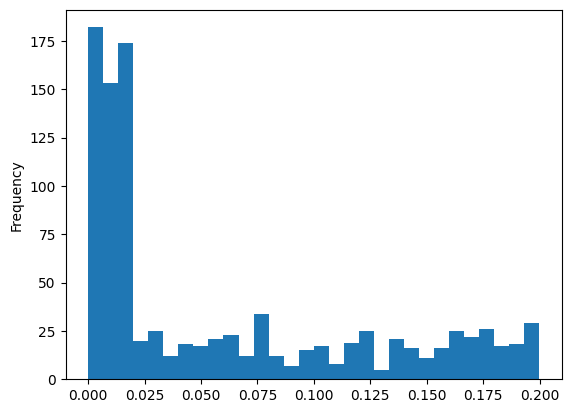

In [33]:
# Dados sem tratamento
df_projeto['CD34'].plot(kind='hist', bins=30)
plt.show()

Dados com transformação logaritmica para CD34

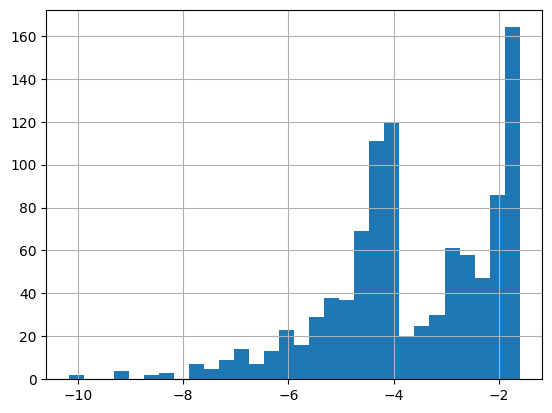

In [34]:
# Dados com transformação logaritmica para CD34
np.log(df_projeto['CD34']).hist(bins=30)
plt.show()

In [35]:
df_projeto['CD34'].describe()

count    1000.000000
mean        0.060034
std         0.063964
min         0.000038
25%         0.010408
50%         0.019465
75%         0.112731
max         0.199757
Name: CD34, dtype: float64

In [36]:
df_projeto['CD34'+'_log'] = np.log(df_projeto['CD34'])
df_projeto.drop('CD34', axis=1, inplace=True)

In [37]:
df_projeto.columns

Index(['TdT', 'MPO', 'CD19_1', 'CD20_1', 'CD22', 'CD3_1', 'CD7', 'BCR-ABL',
       'PML-RARA', 'NMP22', 'TP53', 'PPD', 'IFN-γ', 'IL-2', 'TNF-α', 'Th1',
       'IgG_1', 'IgA_1', 'CD3_2', 'CD4', 'CD8', 'CD19_2', 'CD20_2', 'IgA_2',
       'IgM', 'CD16', 'CD56', 'DHR', 'CH50', 'C3', 'C4', 'FOXP3', 'classe',
       'CD34_log'],
      dtype='object')

Aplicando o mesmo processo para as outras 2 variáveis com cauda longa

> PPD

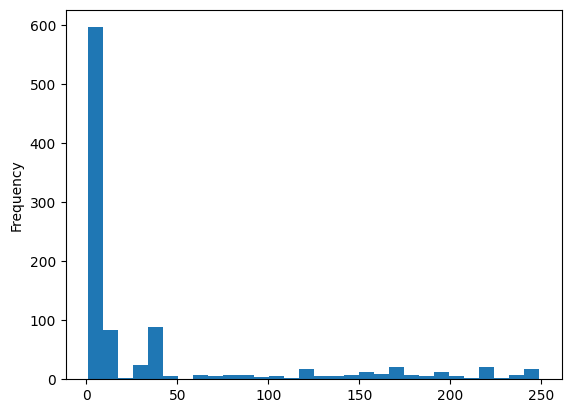

In [38]:
# Dados sem tratamento
df_projeto['PPD'].plot(kind='hist', bins=30)
plt.show()

Dados com transformação logaritmica para PPD


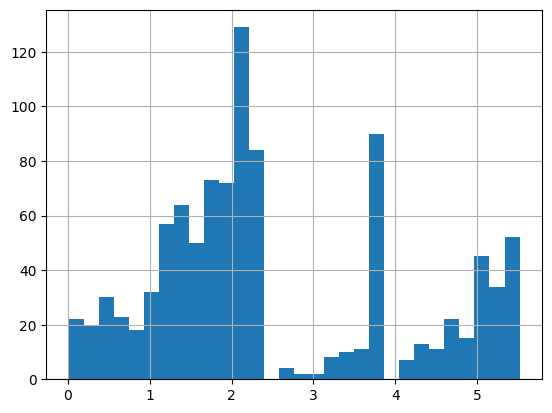

In [39]:
# Dados com transformação logaritmica para PPD
np.log(df_projeto['PPD']).hist(bins=30)
plt.show()

In [40]:
#Substituindo a variável original PPD pelos mesmos dados em escala logaritmica
df_projeto['PPD'+'_log'] = np.log(df_projeto['PPD'])
df_projeto.drop('PPD', axis=1, inplace=True)

In [41]:
df_projeto.columns

Index(['TdT', 'MPO', 'CD19_1', 'CD20_1', 'CD22', 'CD3_1', 'CD7', 'BCR-ABL',
       'PML-RARA', 'NMP22', 'TP53', 'IFN-γ', 'IL-2', 'TNF-α', 'Th1', 'IgG_1',
       'IgA_1', 'CD3_2', 'CD4', 'CD8', 'CD19_2', 'CD20_2', 'IgA_2', 'IgM',
       'CD16', 'CD56', 'DHR', 'CH50', 'C3', 'C4', 'FOXP3', 'classe',
       'CD34_log', 'PPD_log'],
      dtype='object')

> DHR

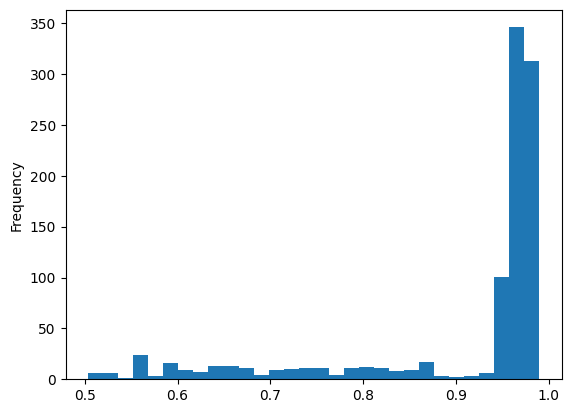

In [42]:
# Dados sem tratamento
df_projeto['DHR'].plot(kind='hist', bins=30)
plt.show()

In [43]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

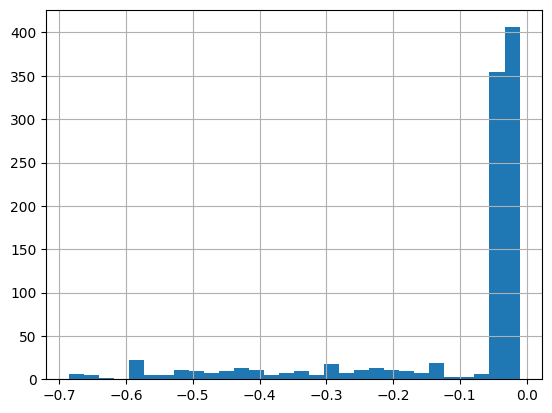

In [44]:
# Dados com transformação logaritmica para DHR
np.log(df_projeto['DHR']).hist(bins=30)
plt.show()

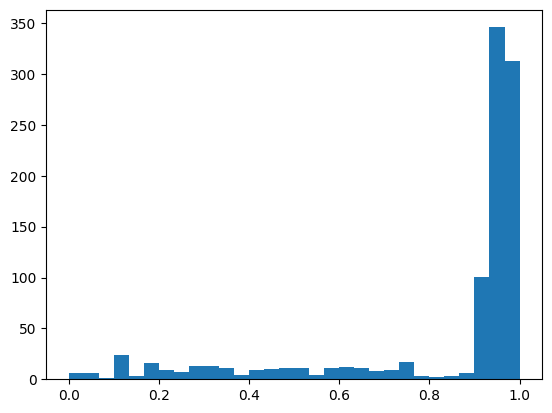

In [45]:
# Dados com normalização
scaler = MinMaxScaler()
dados_padronizados = scaler.fit_transform(df_projeto['DHR'].to_frame())
plt.hist(dados_padronizados, bins=30)
plt.show()

Para esta variável, ao testar todas as possíveis transformações, observei que ela não altera sua distribuição de forma interessante (normalização, padronização nem outras transformaçoes como escala logaritmica ou exponencial). Manterei ela como está.

In [46]:
desc_numericas = df_projeto.describe() #numericas
desc_numericas

,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,...,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.243074,0.252608,0.252441,0.301079,0.306717,5.086000,0.136688,0.281682,1410.617000,3244.770835,...,1450.029066,320.623592,421.617699,447.510144,0.908313,132.639000,233.019000,53.945000,-3.681623,2.510488
std,0.113677,0.120787,0.120602,0.118621,0.115286,2.559914,0.069226,0.160837,808.027206,1028.606652,...,641.958546,185.399715,188.831101,180.779819,0.125089,60.094426,73.910753,20.787258,1.586890,1.522354
min,0.100076,0.102262,0.100437,0.100240,0.101436,1.000000,0.010049,0.100193,515.000000,1026.262586,...,703.186762,70.269555,90.835000,93.257771,0.503670,60.000000,90.000000,10.000000,-10.169551,0.011259
25%,0.146372,0.148469,0.150200,0.192038,0.212423,3.000000,0.083288,0.169156,842.000000,2585.180494,...,986.012645,163.102167,263.943968,316.213570,0.951719,92.000000,180.000000,40.000000,-4.565183,1.470395
50%,0.198089,0.198387,0.199057,0.301079,0.298414,5.000000,0.149010,0.232476,1147.000000,3256.689944,...,1270.491282,292.877234,420.266942,466.642919,0.964429,116.000000,229.000000,55.000000,-3.939141,2.099889
75%,0.338725,0.358607,0.348809,0.409592,0.401273,7.000000,0.196692,0.324549,1670.000000,4110.949533,...,1569.265787,396.634737,586.452359,594.438512,0.977470,143.000000,289.000000,72.000000,-2.182762,3.714128
max,0.498847,0.499975,0.499585,0.498341,0.496797,9.000000,0.249430,0.699100,3569.000000,4997.765525,...,3194.446402,796.898744,749.784414,749.836679,0.989492,299.000000,358.000000,89.000000,-1.610655,5.516486


In [47]:
df_projeto.columns

Index(['TdT', 'MPO', 'CD19_1', 'CD20_1', 'CD22', 'CD3_1', 'CD7', 'BCR-ABL',
       'PML-RARA', 'NMP22', 'TP53', 'IFN-γ', 'IL-2', 'TNF-α', 'Th1', 'IgG_1',
       'IgA_1', 'CD3_2', 'CD4', 'CD8', 'CD19_2', 'CD20_2', 'IgA_2', 'IgM',
       'CD16', 'CD56', 'DHR', 'CH50', 'C3', 'C4', 'FOXP3', 'classe',
       'CD34_log', 'PPD_log'],
      dtype='object')

Neste momento, obtenho o dataset sem missing values, sem constantes e com as vriáveis categóricas em formato booleano

## Valores correlacionados

In [48]:
df_projeto_classes = df_projeto['classe']

In [49]:
df_projeto_num = df_projeto.select_dtypes(include='number').corr()
df_projeto_num.style.background_gradient(cmap='coolwarm')

,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
CD19_1,1.000000,0.704822,0.693752,0.749989,0.739923,0.019575,-0.073669,-0.463674,-0.459872,0.392757,0.332644,0.396640,-0.438788,-0.393870,-0.319914,-0.284299,0.411213,-0.428957,0.336368,0.353058,0.694465,-0.481603
CD20_1,0.704822,1.000000,0.723823,0.745560,0.744944,0.085606,0.037263,-0.485246,-0.446376,0.333591,0.342020,0.412925,-0.390023,-0.372545,-0.320776,-0.309772,0.421285,-0.376961,0.389664,0.348129,0.703478,-0.536429
CD22,0.693752,0.723823,1.000000,0.729660,0.743305,0.024136,0.031735,-0.478440,-0.469373,0.306929,0.385390,0.424806,-0.431149,-0.360406,-0.353081,-0.350336,0.436630,-0.423453,0.392429,0.368528,0.677013,-0.476597
CD3_1,0.749989,0.745560,0.729660,1.000000,0.721689,0.076472,0.046532,-0.440109,-0.393540,0.383740,0.344464,0.458946,-0.491071,-0.409532,-0.402821,-0.373102,0.459963,-0.462748,0.414994,0.394607,0.684679,-0.460120
CD7,0.739923,0.744944,0.743305,0.721689,1.000000,0.047687,-0.070678,-0.451499,-0.405081,0.397909,0.402259,0.437757,-0.459839,-0.454433,-0.345152,-0.342859,0.475050,-0.462925,0.417713,0.393717,0.704341,-0.445099
NMP22,0.019575,0.085606,0.024136,0.076472,0.047687,1.000000,-0.128236,-0.017829,0.040820,0.020838,-0.032188,0.017963,-0.030100,0.082062,-0.046911,0.031149,0.021818,-0.011133,-0.009637,-0.029106,0.054056,-0.013035
TP53,-0.073669,0.037263,0.031735,0.046532,-0.070678,-0.128236,1.000000,0.015478,0.043840,0.005653,0.064368,0.042058,-0.052677,-0.046841,-0.008685,-0.079854,0.036826,-0.051395,0.126733,-0.022775,0.032242,-0.044942
IFN-γ,-0.463674,-0.485246,-0.478440,-0.440109,-0.451499,-0.017829,0.015478,1.000000,0.768988,0.228079,0.171502,0.188294,-0.230803,-0.220709,-0.216476,-0.172332,0.230160,-0.223720,0.142447,0.208692,-0.456770,0.717074
Th1,-0.459872,-0.446376,-0.469373,-0.393540,-0.405081,0.040820,0.043840,0.768988,1.000000,0.225576,0.238339,0.231082,-0.255171,-0.271027,-0.215567,-0.164699,0.236626,-0.227121,0.170310,0.249999,-0.448771,0.743100
CD3_2,0.392757,0.333591,0.306929,0.383740,0.397909,0.020838,0.005653,0.228079,0.225576,1.000000,0.624374,0.612077,-0.704476,-0.640543,-0.608647,-0.547487,0.702741,-0.687924,0.553625,0.621290,0.321560,0.200421


Definimos que o limite de correlacao sera 0.7

In [50]:
limite = 0.7
corr = df_projeto_num.corr()
corr[corr < limite].style.background_gradient(cmap='coolwarm')

,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
CD19_1,nan,nan,nan,nan,nan,0.023349,-0.028334,-0.537818,-0.506828,0.665045,0.669442,nan,-0.700875,-0.678147,-0.668273,-0.665024,0.698423,-0.703191,nan,0.663263,nan,-0.584075
CD20_1,nan,nan,nan,nan,nan,0.048415,0.028143,-0.560776,-0.525218,0.639906,0.654954,0.689928,-0.682376,-0.659780,-0.654589,-0.657513,0.684004,-0.683658,0.696545,0.644886,nan,-0.612368
CD22,nan,nan,nan,nan,nan,0.016126,0.033986,-0.533637,-0.500842,0.660161,0.683530,nan,-0.707270,-0.681229,-0.679151,-0.684971,nan,-0.709055,nan,0.670342,nan,-0.579815
CD3_1,nan,nan,nan,nan,nan,0.042434,0.040968,-0.486501,-0.449249,nan,nan,nan,-0.746735,-0.719516,-0.719630,-0.719179,nan,-0.746431,nan,nan,nan,-0.537961
CD7,nan,nan,nan,nan,nan,0.029622,-0.019580,-0.491007,-0.453798,nan,nan,nan,-0.741005,-0.722705,-0.709005,-0.711107,nan,-0.744104,nan,nan,nan,-0.536463
NMP22,0.023349,0.048415,0.016126,0.042434,0.029622,nan,-0.300599,-0.077527,-0.051054,-0.035661,-0.075458,-0.038203,0.022923,0.082290,-0.003531,0.050870,-0.037452,0.030280,-0.060185,-0.062018,0.031239,-0.074288
TP53,-0.028334,0.028143,0.033986,0.040968,-0.019580,-0.300599,nan,0.065853,0.077380,0.065002,0.105337,0.086360,-0.097541,-0.099681,-0.079770,-0.137093,0.083765,-0.098354,0.147293,0.054457,0.025264,0.018956
IFN-γ,-0.537818,-0.560776,-0.533637,-0.486501,-0.491007,-0.077527,0.065853,nan,nan,0.242906,0.212362,0.185584,-0.201139,-0.225244,-0.225995,-0.210338,0.199947,-0.197892,0.160230,0.236293,-0.549598,nan
Th1,-0.506828,-0.525218,-0.500842,-0.449249,-0.453798,-0.051054,0.077380,nan,nan,0.276852,0.255359,0.225885,-0.240326,-0.267025,-0.261500,-0.244746,0.236537,-0.235081,0.199013,0.275537,-0.517571,nan
CD3_2,0.665045,0.639906,0.660161,nan,nan,-0.035661,0.065002,0.242906,0.276852,nan,nan,nan,-0.982072,-0.974749,-0.970650,-0.958326,nan,-0.981103,nan,nan,0.645441,0.184697


Quero identificar se essas correlacoes estao ligadas a uma classe de resposta especifico - aparentemente não é especifico de uma classe pois os índices de correlacao se mantém uniformes entre as classes

> Valores de correlação para as variáveis considerando a classe _leucemia_

In [51]:
classes = df_projeto['classe'].unique()
c = 0
display(classes[c])

corr = df_projeto[df_projeto['classe'] == classes[c]].select_dtypes(include='number').corr()
display(corr.style.background_gradient(cmap='coolwarm'))

'leucemia'

,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
CD19_1,1.000000,-0.014358,-0.079371,0.158253,0.128875,0.032222,-0.143915,0.072221,-0.122491,0.371108,-0.070865,0.020611,-0.182574,-0.148062,0.045896,0.144393,-0.111698,-0.108694,-0.154588,0.027256,0.020529,-0.009067
CD20_1,-0.014358,1.000000,0.072677,0.143610,0.041316,0.120877,0.081989,-0.050788,0.183617,0.041291,-0.036886,0.186498,0.102849,-0.037694,0.001417,0.180368,0.135330,0.133826,-0.036615,0.037248,-0.046762,-0.132402
CD22,-0.079371,0.072677,1.000000,0.082191,-0.027753,-0.111528,0.109506,-0.153637,-0.118784,-0.215971,0.084052,0.094664,-0.035047,0.116565,-0.143233,0.074713,0.126407,0.045360,0.072582,0.046300,-0.177927,-0.034859
CD3_1,0.158253,0.143610,0.082191,1.000000,0.078461,0.093752,0.106688,-0.224397,0.124786,0.111175,-0.123776,0.031265,-0.018987,-0.053987,0.036545,0.029961,0.036199,0.012663,-0.148936,-0.129408,-0.055833,-0.115149
CD7,0.128875,0.041316,-0.027753,0.078461,1.000000,0.042724,-0.178642,-0.020249,0.191664,0.062459,0.090609,0.039553,-0.016377,-0.262260,0.140482,0.003834,-0.129198,-0.074074,-0.054067,0.080622,0.081276,0.201563
NMP22,0.032222,0.120877,-0.111528,0.093752,0.042724,1.000000,-0.121451,-0.012797,-0.005209,0.086836,-0.031824,-0.028079,0.070805,0.133071,-0.117748,0.098306,0.020707,0.053396,-0.086667,-0.185592,0.012887,0.083242
TP53,-0.143915,0.081989,0.109506,0.106688,-0.178642,-0.121451,1.000000,-0.156875,0.090906,-0.172863,0.157454,-0.024106,-0.115094,0.013210,-0.011108,-0.057496,-0.141832,-0.007025,0.288417,-0.091505,0.020467,-0.147314
IFN-γ,0.072221,-0.050788,-0.153637,-0.224397,-0.020249,-0.012797,-0.156875,1.000000,-0.126690,-0.026483,0.107715,0.095257,-0.133663,0.040647,-0.091170,0.026188,0.021931,-0.082169,-0.000390,-0.030669,-0.079476,-0.300750
Th1,-0.122491,0.183617,-0.118784,0.124786,0.191664,-0.005209,0.090906,-0.126690,1.000000,-0.152534,0.073426,0.012239,-0.032564,-0.189021,0.011998,0.131612,-0.096467,0.238759,0.069916,-0.022687,0.123985,0.110255
CD3_2,0.371108,0.041291,-0.215971,0.111175,0.062459,0.086836,-0.172863,-0.026483,-0.152534,1.000000,0.089881,-0.058736,0.033415,0.006390,-0.038076,0.167173,-0.081756,0.061823,-0.197464,-0.077295,0.084469,-0.018583


> Valores de correlação para as variáveis considerando a classe _cancer_

In [52]:
c += 1
display(classes[c])
corr = df_projeto[df_projeto['classe'] == classes[c]].select_dtypes(include='number').corr()
display(corr.style.background_gradient(cmap='coolwarm'))

'cancer'

,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
CD19_1,1.000000,-0.067574,-0.013335,0.134647,0.136151,-0.010260,-0.177768,0.006924,-0.046167,0.304029,0.030261,-0.078645,-0.166887,-0.134953,0.089441,0.184134,-0.050147,-0.234417,-0.176623,-0.006341,0.022398,-0.110509
CD20_1,-0.067574,1.000000,-0.050244,0.101532,0.020897,0.144327,0.132265,0.016389,0.135753,0.006806,-0.057071,0.033140,0.037968,0.043114,0.011885,0.037962,0.042424,0.189006,0.080895,-0.004119,0.045425,-0.342517
CD22,-0.013335,-0.050244,1.000000,0.012869,0.169952,0.008716,0.079996,-0.047693,-0.229483,-0.130829,0.130630,0.071398,-0.091643,0.100808,-0.007321,-0.067586,0.059600,-0.083569,-0.006567,-0.020754,-0.144896,0.029091
CD3_1,0.134647,0.101532,0.012869,1.000000,-0.106984,0.065813,0.178560,-0.093883,0.030546,0.041512,-0.088588,-0.030924,-0.055768,0.048683,0.005704,-0.039963,0.039494,0.034032,-0.100603,-0.045099,-0.124625,-0.345685
CD7,0.136151,0.020897,0.169952,-0.106984,1.000000,-0.003181,-0.179922,0.084231,0.079378,0.080216,0.166694,-0.048679,-0.056367,-0.276591,0.118432,0.100519,-0.022278,-0.152242,-0.027632,0.050338,0.058437,0.020622
NMP22,-0.010260,0.144327,0.008716,0.065813,-0.003181,1.000000,-0.109352,-0.027280,-0.071191,-0.006658,-0.003775,-0.184773,-0.014915,0.276175,-0.079239,0.075614,-0.037593,-0.060793,-0.152325,-0.148093,0.047013,-0.090194
TP53,-0.177768,0.132265,0.079996,0.178560,-0.179922,-0.109352,1.000000,-0.031944,0.141083,-0.069160,0.089061,0.037599,-0.054298,-0.006368,-0.034115,-0.089637,-0.122213,0.137627,0.155922,-0.065171,-0.104490,-0.164985
IFN-γ,0.006924,0.016389,-0.047693,-0.093883,0.084231,-0.027280,-0.031944,1.000000,-0.038850,-0.151633,0.120695,-0.004331,-0.097557,0.162048,-0.108550,0.004664,0.172770,-0.151084,-0.043333,-0.175468,0.060344,-0.147361
Th1,-0.046167,0.135753,-0.229483,0.030546,0.079378,-0.071191,0.141083,-0.038850,1.000000,-0.120669,0.104859,0.128068,-0.028705,-0.204777,-0.055844,0.055130,-0.065764,0.211706,0.125173,0.079729,0.065732,-0.141862
CD3_2,0.304029,0.006806,-0.130829,0.041512,0.080216,-0.006658,-0.069160,-0.151633,-0.120669,1.000000,0.192710,-0.036559,0.010911,-0.015267,-0.044306,-0.005716,-0.186652,0.011442,-0.042458,-0.083797,0.149716,0.034479


> Valores de correlação para as variáveis considerando a classe _BCG_

In [53]:
c += 1
display(classes[c])
corr = df_projeto[df_projeto['classe'] == classes[c]].select_dtypes(include='number').corr()
display(corr.style.background_gradient(cmap='coolwarm'))

'BCG'

,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
CD19_1,1.000000,-0.037232,-0.072015,0.122279,-0.104264,-0.105347,-0.170911,0.029404,-0.089444,-0.137217,-0.151996,0.126080,-0.261869,0.089017,-0.274752,0.076222,-0.119898,0.045358,0.101074,-0.010486,0.111854,-0.068396
CD20_1,-0.037232,1.000000,-0.130037,-0.063643,0.194446,-0.021883,0.105478,0.043067,0.038650,0.084813,0.023240,-0.159059,0.090978,-0.114392,0.096534,0.113379,0.130719,-0.027579,0.023260,-0.048004,-0.068484,-0.015093
CD22,-0.072015,-0.130037,1.000000,-0.065375,0.037547,0.022839,0.043444,-0.083497,-0.043403,0.207257,0.075659,0.062213,-0.187068,0.060911,-0.045911,-0.087248,0.073776,-0.031870,-0.009421,0.241622,-0.032579,-0.064402
CD3_1,0.122279,-0.063643,-0.065375,1.000000,-0.110502,0.101577,0.063234,0.098413,0.115734,-0.003141,-0.259928,0.045964,-0.047347,-0.017061,-0.300866,0.059121,-0.137496,-0.034326,0.079616,0.064567,-0.025306,-0.063659
CD7,-0.104264,0.194446,0.037547,-0.110502,1.000000,0.007173,-0.059451,-0.014661,0.074234,0.094625,-0.045738,-0.028601,0.007325,-0.186502,-0.075331,0.145242,0.031872,-0.119907,0.051714,-0.038399,0.013484,0.013706
NMP22,-0.105347,-0.021883,0.022839,0.101577,0.007173,1.000000,-0.082275,0.009419,0.241419,-0.033317,-0.228629,0.170228,0.075543,0.130366,0.039059,0.083508,-0.036528,0.042855,0.130127,0.075287,-0.020769,0.036874
TP53,-0.170911,0.105478,0.043444,0.063234,-0.059451,-0.082275,1.000000,-0.092809,-0.022247,0.006502,-0.036484,0.021643,0.008837,0.047273,0.153049,-0.114853,0.126353,-0.015239,0.006958,-0.137548,0.097667,-0.194360
IFN-γ,0.029404,0.043067,-0.083497,0.098413,-0.014661,0.009419,-0.092809,1.000000,0.034105,-0.081990,-0.216645,-0.028346,0.009316,0.035284,0.037932,0.009511,-0.140982,-0.064373,-0.045934,-0.117157,0.018380,-0.081548
Th1,-0.089444,0.038650,-0.043403,0.115734,0.074234,0.241419,-0.022247,0.034105,1.000000,-0.091817,0.136023,0.173322,-0.068023,-0.022788,0.052248,0.074309,0.127598,-0.206249,-0.036385,-0.028234,-0.119691,0.105130
CD3_2,-0.137217,0.084813,0.207257,-0.003141,0.094625,-0.033317,0.006502,-0.081990,-0.091817,1.000000,0.052178,-0.079545,-0.307846,0.157972,-0.141143,-0.064900,0.010653,-0.233116,0.056941,0.096740,-0.045887,-0.077665


> Valores de correlação para as variáveis considerando a classe _imunodeficiência_

In [54]:
c += 1
display(classes[c])
corr = df_projeto[df_projeto['classe'] == classes[c]].select_dtypes(include='number').corr()
display(corr.style.background_gradient(cmap='coolwarm'))

'imunodeficiencia'

,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,CD34_log,PPD_log
CD19_1,1.000000,-0.005338,0.007025,0.156493,-0.072970,-0.133156,0.072632,-0.230490,0.032773,-0.112258,-0.027546,0.044167,-0.023671,-0.006589,0.119829,0.105234,-0.052151,0.022382,0.079522,0.087337,-0.046650,0.082871
CD20_1,-0.005338,1.000000,0.007095,-0.193553,-0.188952,0.108379,0.055700,-0.068092,-0.252928,-0.104182,0.168779,-0.205549,0.205831,0.059682,-0.007467,-0.047350,-0.054973,0.220661,0.026257,-0.171370,-0.015533,-0.100720
CD22,0.007025,0.007095,1.000000,0.045253,-0.052965,0.119154,0.069830,0.097024,0.004955,0.072832,-0.094648,-0.097723,-0.039088,-0.105576,-0.028703,0.096226,0.121158,-0.090231,0.027139,-0.028616,0.132192,-0.119364
CD3_1,0.156493,-0.193553,0.045253,1.000000,-0.121517,0.067960,0.055722,-0.099319,-0.028073,-0.059242,-0.059514,0.139385,-0.251469,0.179763,-0.057172,0.157316,-0.099369,-0.046574,0.198491,0.063193,-0.079767,0.206568
CD7,-0.072970,-0.188952,-0.052965,-0.121517,1.000000,0.070938,-0.111218,-0.040973,0.145307,0.259532,-0.001133,0.054576,-0.075597,0.064663,0.039351,0.135454,0.127668,0.034477,0.160523,-0.045512,-0.151924,-0.013331
NMP22,-0.133156,0.108379,0.119154,0.067960,0.070938,1.000000,-0.215441,-0.021926,0.173028,-0.086720,-0.042985,0.037047,-0.096201,0.240067,0.062451,0.033602,-0.019300,0.066372,-0.107282,-0.090879,0.111636,-0.007919
TP53,0.072632,0.055700,0.069830,0.055722,-0.111218,-0.215441,1.000000,0.082825,-0.192743,0.089833,-0.001478,0.047020,-0.026521,-0.139674,-0.113354,0.043333,0.020811,-0.164983,0.191645,-0.075121,0.178225,-0.130001
IFN-γ,-0.230490,-0.068092,0.097024,-0.099319,-0.040973,-0.021926,0.082825,1.000000,0.133452,0.119366,-0.018957,0.080065,-0.044582,0.134859,-0.102696,0.055565,0.108289,-0.041489,0.054181,-0.016206,-0.067437,-0.014952
Th1,0.032773,-0.252928,0.004955,-0.028073,0.145307,0.173028,-0.192743,0.133452,1.000000,-0.137372,0.031752,0.121686,-0.187157,0.095973,0.002017,0.026948,-0.040963,-0.028619,-0.078120,0.040043,-0.097954,0.035287
CD3_2,-0.112258,-0.104182,0.072832,-0.059242,0.259532,-0.086720,0.089833,0.119366,-0.137372,1.000000,0.103485,0.032429,-0.072480,-0.010968,-0.186800,0.031736,0.181026,-0.135103,0.041665,0.036079,-0.157856,-0.052810


In [56]:
col_baixa_corr = list(corr[corr < limite].columns)
len(col_baixa_corr)

22

In [55]:
df_projeto_classes

0      leucemia
1      leucemia
2      leucemia
3      leucemia
4      leucemia
         ...   
995    leucemia
996         BCG
997    leucemia
998         BCG
999         BCG
Name: classe, Length: 1000, dtype: object

Salvo nesse momento o dataframe com as colunas com valor de correlacao menor que 0.7 e as classes

In [57]:
df_projeto_cat

['IL-2', 'TNF-α', 'IgG_1', 'IgA_1', 'IgA_2', 'IgM', 'FOXP3']

In [58]:
#juntar com a coluna classe
df_projeto = pd.concat([df_projeto[col_baixa_corr],df_projeto[df_projeto_cat] ,df_projeto['classe'] ], axis =1)
df_projeto


,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,...,CD34_log,PPD_log,IL-2,TNF-α,IgG_1,IgA_1,IgA_2,IgM,FOXP3,classe
0,0.471228,0.398837,0.233216,0.329756,0.417118,9,0.072077,0.236097,1219,4777.735596,...,-2.125596,0.588027,Baixo,Baixo,Alto,Baixo,Alto,Alto,Normal,leucemia
1,0.292042,0.370941,0.253135,0.340733,0.350616,7,0.099415,0.195858,1431,2728.722124,...,-2.185510,3.714128,Baixo,Baixo,Alto,Baixo,Alto,Alto,Normal,leucemia
2,0.372872,0.257518,0.451758,0.487803,0.399385,4,0.206770,0.210132,876,3496.556667,...,-1.739342,2.057824,Baixo,Baixo,Alto,Baixo,Alto,Alto,Normal,leucemia
3,0.469943,0.495637,0.351360,0.332752,0.487439,4,0.087026,0.111679,1350,4422.935251,...,-2.544432,2.230950,Baixo,Baixo,Alto,Baixo,Alto,Alto,Normal,leucemia
4,0.349343,0.381742,0.220939,0.479723,0.453555,8,0.154890,0.238945,647,3021.382901,...,-2.795526,0.083765,Baixo,Baixo,Alto,Baixo,Alto,Alto,Normal,leucemia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.393222,0.458290,0.346061,0.492897,0.382239,9,0.208846,0.187005,1411,4057.575204,...,-1.789109,0.756665,Baixo,Baixo,Alto,Baixo,Alto,Alto,Normal,leucemia
996,0.193642,0.177386,0.121604,0.184222,0.252370,7,0.135599,0.539736,3317,4844.952962,...,-4.588500,5.410892,Alto,Alto,Alto,Alto,Alto,Alto,Normal,BCG
997,0.326550,0.380776,0.316968,0.457663,0.484900,8,0.010049,0.193008,1340,4444.912410,...,-3.011878,2.160236,Baixo,Baixo,Alto,Baixo,Alto,Alto,Normal,leucemia
998,0.142724,0.103813,0.127491,0.301079,0.206177,2,0.090487,0.542345,2461,3402.061077,...,-6.869732,4.441393,Alto,Alto,Alto,Alto,Alto,Alto,Normal,BCG


In [59]:
df_projeto.columns

Index(['CD19_1', 'CD20_1', 'CD22', 'CD3_1', 'CD7', 'NMP22', 'TP53', 'IFN-γ',
       'Th1', 'CD3_2', 'CD4', 'CD8', 'CD19_2', 'CD20_2', 'CD16', 'CD56', 'DHR',
       'CH50', 'C3', 'C4', 'CD34_log', 'PPD_log', 'IL-2', 'TNF-α', 'IgG_1',
       'IgA_1', 'IgA_2', 'IgM', 'FOXP3', 'classe'],
      dtype='object')

In [60]:
Igs = df_projeto[['IgA_1', 'IgA_2', 'IgM', 'IgG_1']]
Igs

,IgA_1,IgA_2,IgM,IgG_1
0,Baixo,Alto,Alto,Alto
1,Baixo,Alto,Alto,Alto
2,Baixo,Alto,Alto,Alto
3,Baixo,Alto,Alto,Alto
4,Baixo,Alto,Alto,Alto
...,...,...,...,...
995,Baixo,Alto,Alto,Alto
996,Alto,Alto,Alto,Alto
997,Baixo,Alto,Alto,Alto
998,Alto,Alto,Alto,Alto


Aplicamos a moda sobre o grupo das imunoglobulinas, para termos uma medida resumo para categórica

In [61]:
Igs = Igs.mode(axis=1)
Igs.rename(columns = {0 : 'Igs'},inplace=True)
df_projeto = pd.concat([df_projeto,Igs],axis=1)

In [62]:
df_projeto.columns

Index(['CD19_1', 'CD20_1', 'CD22', 'CD3_1', 'CD7', 'NMP22', 'TP53', 'IFN-γ',
       'Th1', 'CD3_2', 'CD4', 'CD8', 'CD19_2', 'CD20_2', 'CD16', 'CD56', 'DHR',
       'CH50', 'C3', 'C4', 'CD34_log', 'PPD_log', 'IL-2', 'TNF-α', 'IgG_1',
       'IgA_1', 'IgA_2', 'IgM', 'FOXP3', 'classe', 'Igs'],
      dtype='object')

Excluindo colunas de Ig agora agrupadas em _Igs_

In [63]:
del df_projeto['IgA_1']
del df_projeto['IgA_2']
del df_projeto['IgM']
del df_projeto['IgG_1']


In [64]:
df_projeto.columns

Index(['CD19_1', 'CD20_1', 'CD22', 'CD3_1', 'CD7', 'NMP22', 'TP53', 'IFN-γ',
       'Th1', 'CD3_2', 'CD4', 'CD8', 'CD19_2', 'CD20_2', 'CD16', 'CD56', 'DHR',
       'CH50', 'C3', 'C4', 'CD34_log', 'PPD_log', 'IL-2', 'TNF-α', 'FOXP3',
       'classe', 'Igs'],
      dtype='object')

Agrupamento de variáveis por categoria

In [65]:


'''
Justificativa dos grupos


CD_19 , CD_20,CD20_2, CD_22, - LINFÓCITO B
CD_3, CD3_2, CD4, CD8, CD_7, Th1, - LINFÓCITO T
CD16, CD56 - NK
CD_34_log - MARCADOR CÉLULAS HEMATOPOIÉTICAS (LEUCEMIA)
PPD_log - BCG 
DHR,e C3, C4 CH50 (marcador sistema complemento) - MARCADOR IMUNODEFICIÊNCIA


NMP22 (câncer bexiga), FOXP3 - marcador para câncer
TP53 - regulador do ciclo celular (supressor tumoral)

IFN-γ, IL-2, TNF-α - CITOCINAS'''

'\nJustificativa dos grupos\n\n\nCD_19 , CD_20,CD20_2, CD_22, - LINFÓCITO B\nCD_3, CD3_2, CD4, CD8, CD_7, Th1, - LINFÓCITO T\nCD16, CD56 - NK\nCD_34_log - MARCADOR CÉLULAS HEMATOPOIÉTICAS (LEUCEMIA)\nPPD_log - BCG \nDHR,e C3, C4 CH50 (marcador sistema complemento) - MARCADOR IMUNODEFICIÊNCIA\n\n\nNMP22 (câncer bexiga), FOXP3 - marcador para câncer\nTP53 - regulador do ciclo celular (supressor tumoral)\n\nIFN-γ, IL-2, TNF-α - CITOCINAS'

De modo a reduzir o número de colunas, agruparei utilizando a média os marcadores de linfoócito T e B, marcadores de câncer e BCG e citocinas em seus respectivos grupos

In [66]:
df_projeto.columns

Index(['CD19_1', 'CD20_1', 'CD22', 'CD3_1', 'CD7', 'NMP22', 'TP53', 'IFN-γ',
       'Th1', 'CD3_2', 'CD4', 'CD8', 'CD19_2', 'CD20_2', 'CD16', 'CD56', 'DHR',
       'CH50', 'C3', 'C4', 'CD34_log', 'PPD_log', 'IL-2', 'TNF-α', 'FOXP3',
       'classe', 'Igs'],
      dtype='object')

In [67]:
Lin_Bs= df_projeto[['CD19_1', 'CD19_2','CD20_1','CD20_2', 'CD22']]
Lin_Bs

,CD19_1,CD19_2,CD20_1,CD20_2,CD22
0,0.471228,949.930723,0.398837,315.361867,0.233216
1,0.292042,1078.800779,0.370941,161.418609,0.253135
2,0.372872,1265.581855,0.257518,296.797741,0.451758
3,0.469943,1515.262148,0.495637,89.518480,0.351360
4,0.349343,1142.025578,0.381742,215.929093,0.220939
...,...,...,...,...,...
995,0.393222,942.280083,0.458290,233.855081,0.346061
996,0.193642,726.591600,0.177386,153.752428,0.121604
997,0.326550,1175.938546,0.380776,129.768967,0.316968
998,0.142724,1084.735070,0.103813,192.912761,0.127491


In [68]:
Lin_B = pd.DataFrame(Lin_Bs.mean(axis=1))
Lin_B.rename(columns = {0:'Lin_B'}, inplace = True)
Lin_B

,Lin_B
0,253.279174
1,248.227101
2,312.692349
3,321.219514
4,271.781339
...,...
995,235.466548
996,176.167332
997,261.346361
998,255.604372


Substituindo os valores de marcadores de linfócito B pela média dos marcadores na coluna _Lin_B_

In [69]:
df_projeto = pd.concat([df_projeto,Lin_B],axis=1)

In [70]:
del df_projeto['CD19_1']
del df_projeto['CD19_2']
del df_projeto['CD20_1']
del df_projeto['CD20_2']
del df_projeto['CD22']


In [71]:
df_projeto.columns

Index(['CD3_1', 'CD7', 'NMP22', 'TP53', 'IFN-γ', 'Th1', 'CD3_2', 'CD4', 'CD8',
       'CD16', 'CD56', 'DHR', 'CH50', 'C3', 'C4', 'CD34_log', 'PPD_log',
       'IL-2', 'TNF-α', 'FOXP3', 'classe', 'Igs', 'Lin_B'],
      dtype='object')

Aplicando o mesmo processo para marcadores de linfócito T

In [72]:
Lin_Ts= df_projeto[['CD3_1', 'CD3_2', 'CD4', 'CD8', 'CD7','Th1']]
Lin_Ts

,CD3_1,CD3_2,CD4,CD8,CD7,Th1
0,0.329756,4777.735596,3239.633754,1133.778616,0.417118,1219
1,0.340733,2728.722124,2408.093692,1502.023593,0.350616,1431
2,0.487803,3496.556667,2746.924144,1680.599418,0.399385,876
3,0.332752,4422.935251,2411.783812,1641.341596,0.487439,1350
4,0.479723,3021.382901,1971.979426,1694.129006,0.453555,647
...,...,...,...,...,...,...
995,0.492897,4057.575204,2384.077799,1439.768913,0.382239,1411
996,0.184222,4844.952962,1644.072391,1389.062125,0.252370,3317
997,0.457663,4444.912410,1759.541029,1411.231399,0.484900,1340
998,0.301079,3402.061077,2472.751248,1567.002717,0.206177,2461


In [73]:
Lin_T = pd.DataFrame(Lin_Ts.mean(axis=1))
Lin_T.rename(columns = {0:'Lin_T'}, inplace = True)
df_projeto = pd.concat([df_projeto,Lin_T],axis=1)

Deletando as colunas agora agrupadas em _Lin_T_

In [74]:
del df_projeto['CD3_1']
del df_projeto['CD3_2']
del df_projeto['CD4']
del df_projeto['CD8']
del df_projeto['CD7']
del df_projeto['Th1']

In [75]:
df_projeto.columns

Index(['NMP22', 'TP53', 'IFN-γ', 'CD16', 'CD56', 'DHR', 'CH50', 'C3', 'C4',
       'CD34_log', 'PPD_log', 'IL-2', 'TNF-α', 'FOXP3', 'classe', 'Igs',
       'Lin_B', 'Lin_T'],
      dtype='object')

Aplicando o mesmo processo para marcadores de imunodeficiência (sistema complemento)

In [76]:
imunodef= df_projeto[['DHR', 'C3', 'C4', 'CH50']]
imunodef = pd.DataFrame(imunodef.mean(axis=1))

imunodef.rename(columns = {0:'imunodef'}, inplace = True)
df_projeto = pd.concat([df_projeto,imunodef],axis=1)

In [77]:
del df_projeto['DHR']
del df_projeto['C3']
del df_projeto['C4']
del df_projeto['CH50']

In [78]:
df_projeto.columns

Index(['NMP22', 'TP53', 'IFN-γ', 'CD16', 'CD56', 'CD34_log', 'PPD_log', 'IL-2',
       'TNF-α', 'FOXP3', 'classe', 'Igs', 'Lin_B', 'Lin_T', 'imunodef'],
      dtype='object')

Aplicando o processo para marcadores de citocinas - moda!

In [79]:
citoc= df_projeto[['IFN-γ', 'IL-2', 'TNF-α']]
citoc = pd.DataFrame(citoc.mode(axis=1))

citoc.rename(columns = {0:'citoc'}, inplace = True)
df_projeto = pd.concat([df_projeto,citoc],axis=1)

In [80]:
del df_projeto['IFN-γ']
del df_projeto['IL-2']
del df_projeto['TNF-α']

In [81]:
df_projeto.columns

Index(['NMP22', 'TP53', 'CD16', 'CD56', 'CD34_log', 'PPD_log', 'FOXP3',
       'classe', 'Igs', 'Lin_B', 'Lin_T', 'imunodef', 'citoc'],
      dtype='object')

Aplicando para marcadores de células NK

In [82]:
nk= df_projeto[['CD16', 'CD56']]
nk = pd.DataFrame(nk.mean(axis=1))

nk.rename(columns = {0:'nk'}, inplace = True)
df_projeto = pd.concat([df_projeto,nk],axis=1)

In [83]:
del df_projeto['CD16']
del df_projeto['CD56']

In [84]:
df_projeto.columns

Index(['NMP22', 'TP53', 'CD34_log', 'PPD_log', 'FOXP3', 'classe', 'Igs',
       'Lin_B', 'Lin_T', 'imunodef', 'citoc', 'nk'],
      dtype='object')

Aplicando para marcadores de câncer - media para NMP22 e TP53. Como FOXP3 é dessa categoria biológica mas é categórica ele não entra na concatenação

In [84]:
#não posso excluí-lo pois possui uma frequência não desprezível de categorias

df_projeto['FOXP3'].describe(include = 'categorical')

count       1000
unique         2
top       Normal
freq         760
Name: FOXP3, dtype: object

In [85]:
#não posso excluí-lo pois possui uma frequência não desprezível de categorias

df_projeto['Igs'].describe(include = 'categorical')

count     1000
unique       2
top       Alto
freq       760
Name: Igs, dtype: object

In [86]:
#não posso excluí-lo pois possui uma frequência não desprezível de categorias

df_projeto['citoc'].describe(include = 'categorical')

count      1000
unique        2
top       Baixo
freq        736
Name: citoc, dtype: object

In [87]:
cancer= df_projeto[['NMP22', 'TP53']]
cancer = pd.DataFrame(cancer.mean(axis=1))

cancer.rename(columns = {0:'cancer'}, inplace = True)
df_projeto = pd.concat([df_projeto,cancer],axis=1)

In [88]:
del df_projeto['NMP22']
del df_projeto['TP53']


Colunas agrupadas por grupo biológico - 11 colunas

In [89]:
df_projeto

,CD34_log,PPD_log,FOXP3,classe,Igs,Lin_B,Lin_T,imunodef,citoc,nk,cancer
0,-2.125596,0.588027,Normal,leucemia,Alto,253.279174,1728.482473,91.491977,Baixo,321.980644,4.536039
1,-2.185510,3.714128,Normal,leucemia,Alto,248.227101,1345.088460,137.743185,Baixo,287.226512,3.549707
2,-1.739342,2.057824,Normal,leucemia,Alto,312.692349,1466.827903,87.992846,Baixo,270.751402,2.103385
3,-2.544432,2.230950,Normal,leucemia,Alto,321.219514,1637.813475,98.490612,Baixo,547.348692,2.043513
4,-2.795526,0.083765,Normal,leucemia,Alto,271.781339,1222.570768,82.988935,Baixo,195.616613,4.077445
...,...,...,...,...,...,...,...,...,...,...,...
995,-1.789109,0.756665,Normal,leucemia,Alto,235.466548,1548.882842,97.991512,Baixo,357.325619,4.604423
996,-4.588500,5.410892,Normal,BCG,Alto,176.167332,1865.920678,118.489333,Alto,349.480813,3.567799
997,-3.011878,2.160236,Normal,leucemia,Alto,261.346361,1492.771234,84.991646,Baixo,413.386494,4.005024
998,-6.869732,4.441393,Normal,BCG,Alto,255.604372,1650.553716,103.988566,Alto,426.502397,1.045244


## Aplicando Feature Selection para seguir com o processamento com menos variáveis 

In [90]:
classes = df_projeto['classe']

### Análise gráfica para contínuas (bivariada)

In [91]:
df_projeto.columns

Index(['CD34_log', 'PPD_log', 'FOXP3', 'classe', 'Igs', 'Lin_B', 'Lin_T',
       'imunodef', 'citoc', 'nk', 'cancer'],
      dtype='object')

In [92]:
num_columns = df_projeto.select_dtypes(include="number").columns
num_columns 

Index(['CD34_log', 'PPD_log', 'Lin_B', 'Lin_T', 'imunodef', 'nk', 'cancer'], dtype='object')

In [93]:
df_plot = pd.concat([df_projeto[num_columns],df_projeto['classe']],axis=1)
df_plot


,CD34_log,PPD_log,Lin_B,Lin_T,imunodef,nk,cancer,classe
0,-2.125596,0.588027,253.279174,1728.482473,91.491977,321.980644,4.536039,leucemia
1,-2.185510,3.714128,248.227101,1345.088460,137.743185,287.226512,3.549707,leucemia
2,-1.739342,2.057824,312.692349,1466.827903,87.992846,270.751402,2.103385,leucemia
3,-2.544432,2.230950,321.219514,1637.813475,98.490612,547.348692,2.043513,leucemia
4,-2.795526,0.083765,271.781339,1222.570768,82.988935,195.616613,4.077445,leucemia
...,...,...,...,...,...,...,...,...
995,-1.789109,0.756665,235.466548,1548.882842,97.991512,357.325619,4.604423,leucemia
996,-4.588500,5.410892,176.167332,1865.920678,118.489333,349.480813,3.567799,BCG
997,-3.011878,2.160236,261.346361,1492.771234,84.991646,413.386494,4.005024,leucemia
998,-6.869732,4.441393,255.604372,1650.553716,103.988566,426.502397,1.045244,BCG


Testando combinações de variáveis

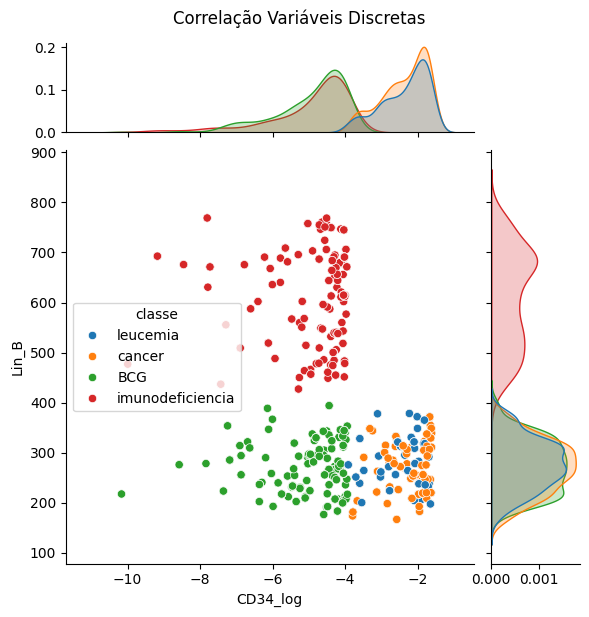

In [94]:
# Gráfico das variáveis que conseguem separar as classes dos daods

p = sns.jointplot(
    x=df_plot['CD34_log'],
    y=df_plot['Lin_B'],
    hue="classe",
    height=6,
    ratio=4,
    marginal_ticks=True,
    data=df_plot,
    )
p.fig.suptitle(f"Correlação Variáveis Discretas", y=1.02)
p.set_axis_labels(xlabel='CD34_log', ylabel='Lin_B')
plt.show()

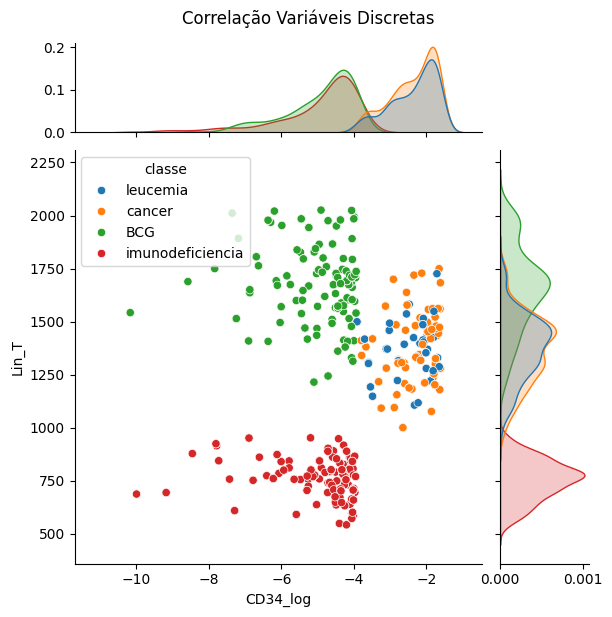

In [104]:
# Gráfico das variáveis que conseguem separar as classes dos daods

p = sns.jointplot(
    x=df_plot['CD34_log'],
    y=df_plot['Lin_T'],
    hue="classe",
    height=6,
    ratio=4,
    marginal_ticks=True,
    data=df_plot,
    )
p.fig.suptitle(f"Correlação Variáveis Discretas", y=1.02)
p.set_axis_labels(xlabel='CD34_log', ylabel='Lin_T')
plt.show()

Variáveis que geravam o padrão abaixo foram excluidas (nk, cancer, imunodef)

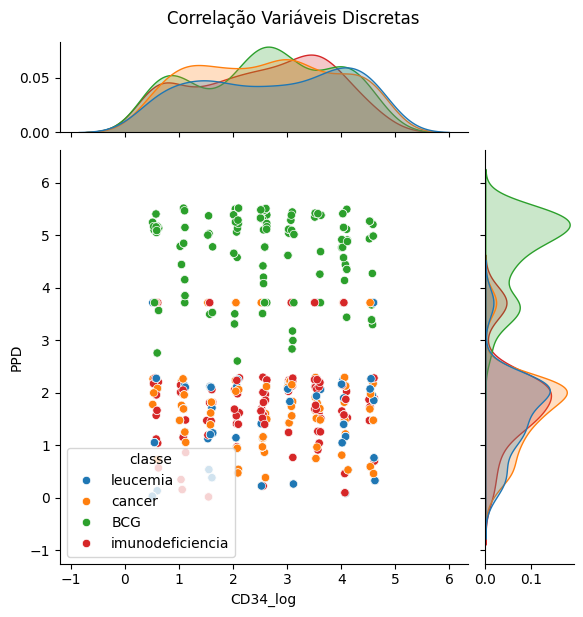

In [95]:
# Gráfico das variáveis que conseguem separar as classes dos daods

p = sns.jointplot(
    x=df_plot['cancer'],
    y=df_plot[ 'PPD_log'],
    hue="classe",
    height=6,
    ratio=4,
    marginal_ticks=True,
    data=df_plot,
    )
p.fig.suptitle(f"Correlação Variáveis Discretas", y=1.02)
p.set_axis_labels(xlabel='CD34_log', ylabel='PPD')
plt.show()

Variáveis capazes de distinguir grupos foram analisadas para correlacao gráfica (CD34_log, Lin_B, Lin_T e PPD_log)

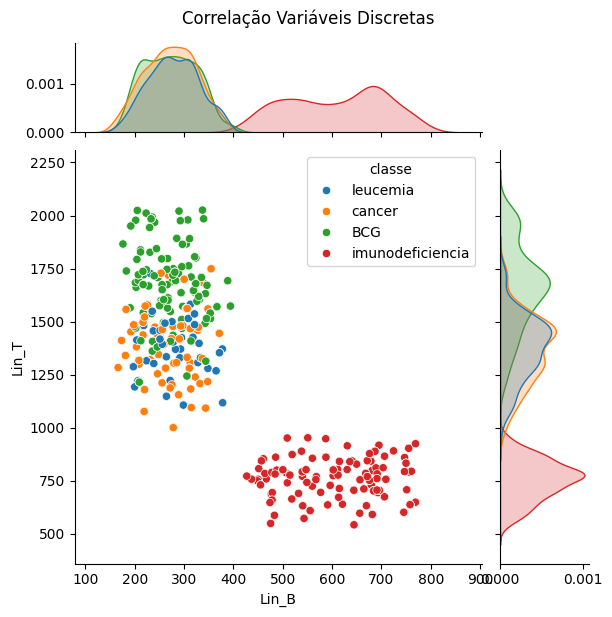

In [96]:
# Gráfico das variáveis que conseguem separar as classes dos daods

p = sns.jointplot(
    x=df_plot['Lin_B'],
    y=df_plot['Lin_T'],
    hue="classe",
    height=6,
    ratio=4,
    marginal_ticks=True,
    data=df_plot,
    )
p.fig.suptitle(f"Correlação Variáveis Discretas", y=1.02)
p.set_axis_labels(xlabel='Lin_B', ylabel='Lin_T')
plt.show()

In [97]:
df_num_rel = df_plot[['CD34_log','Lin_B','Lin_T', 'PPD_log']]
df_num_rel = pd.concat([df_num_rel,classes],axis=1)


In [98]:
df_num_rel

,CD34_log,Lin_B,Lin_T,PPD_log,classe
0,-2.125596,253.279174,1728.482473,0.588027,leucemia
1,-2.185510,248.227101,1345.088460,3.714128,leucemia
2,-1.739342,312.692349,1466.827903,2.057824,leucemia
3,-2.544432,321.219514,1637.813475,2.230950,leucemia
4,-2.795526,271.781339,1222.570768,0.083765,leucemia
...,...,...,...,...,...
995,-1.789109,235.466548,1548.882842,0.756665,leucemia
996,-4.588500,176.167332,1865.920678,5.410892,BCG
997,-3.011878,261.346361,1492.771234,2.160236,leucemia
998,-6.869732,255.604372,1650.553716,4.441393,BCG


### Análise por tabela de frequências para categóricas

In [99]:
def calcula_indicadores(
    independente: str,
    dependente: str,
    positivo: str,
    negativo: str,
    df: pd.DataFrame,
    categoria: bool = False,
    bins: int = 5,
) -> pd.DataFrame:
    """
    Função para calcular os indicadores de risco, odds, odds ratio,
    log odds e woe para uma variável independente em relação a uma
    variável dependente.
        Parametros:
            independente: str - Nome da variável independente
                                (coluna do DataFrame)
            dependente: str - Nome da variável dependente
                                (coluna do DataFrame)
            positivo: str - Valor da variável dependente que será
                            considerado como positivo (evento de interesse)
            negativo: str - Valor da variável dependente que será
                            considerado como negativo (evento contrário ao
                            de interesse)
            df: pd.DataFrame - DataFrame contendo as variáveis
            categoria: bool - Se True, a variável independente será
                                categorizada em bins (quantis) antes do
                                cálculo dos indicadores. Default é False.
            bins: int - Número de bins (quantis) para categorizar a
                        variável independente, caso categoria seja True.
                        Default é 5
        Retorna:
            pd.DataFrame - DataFrame contendo os indicadores calculados
            para cada categoria da variável independente.
    """
    if categoria:
        df[independente + "_cat"] = pd.qcut(x=df[independente], q=bins)
        independente += "_cat"

    tab = pd.crosstab(df[independente], df[dependente], margins=True)
    odds_all = tab.iloc[2, 1] / tab.iloc[2, 0]
    tab = (
        tab.assign(
            prob=tab["All"] / tab.loc["All", "All"]
        )  # Probabilidade de ser mulher ou homem no conjunto de dados
        .assign(
            risck_event=tab[positivo] / tab["All"]
        )  # Risco do evento (probabilidede) de uma mulher ou de um homem estar doente
        .assign(
            odds=tab[positivo] / tab[negativo]
        )  # Chance (odds) de uma mulher ou de um homem estar doente
        .assign(
            odds_ratio=(tab.iloc[:, 1] / tab.iloc[:, 0]) / (odds_all)
        )  # A razão entre as chances de estar doente para mulheres e homens
        .assign(
            log_odd=np.log(tab.loc[:, positivo] / tab.loc[:, negativo])
        )  # Logaritmo da chance
        .assign(
            woe=np.log(  # Logaritmo da razão da chance ou Weigth of Evidence
                (tab.iloc[:, 1] / tab.iloc[:, 0]) / (odds_all)
            )
        )
    )
    tab["log_odd"] = [x if x != np.inf * -1 else np.nan for x in tab["log_odd"]]
    tab["woe"] = [x if x != np.inf * -1 else np.nan for x in tab["woe"]]

    print(f"Flag {negativo}: {tab.loc['All', negativo]}")
    print(f"Flag {positivo}: {tab.loc['All', positivo]}")
    print(f"Total: {tab.loc['All', 'All']}")

    if categoria:
        df.drop(independente, axis="columns", inplace=True)

    return tab

In [133]:
df_projeto_cat = df_projeto.select_dtypes(include="object")

In [137]:
df_projeto_cat

,FOXP3,classe,Igs,citoc
0,Normal,leucemia,Alto,Baixo
1,Normal,leucemia,Alto,Baixo
2,Normal,leucemia,Alto,Baixo
3,Normal,leucemia,Alto,Baixo
4,Normal,leucemia,Alto,Baixo
...,...,...,...,...
995,Normal,leucemia,Alto,Baixo
996,Normal,BCG,Alto,Alto
997,Normal,leucemia,Alto,Baixo
998,Normal,BCG,Alto,Alto


In [102]:
#FOXP3 diferencia imunodef 
c = 0
positivo = "BCG"
negativo = "cancer"
calcula_indicadores(
    independente=df_projeto.select_dtypes(include="object").columns[c],
    dependente="classe",
    positivo=positivo,
    negativo=negativo,
    df=df_projeto.select_dtypes(include="object"),)

Flag cancer: 269
Flag BCG: 264
Total: 1000


classe,BCG,cancer,imunodeficiencia,leucemia,All,prob,risck_event,odds,odds_ratio,log_odd,woe
FOXP3,,,,,,,,,,,
Alterado,0,0,240,0,240,0.24,0.000000,NaN,NaN,NaN,NaN
Normal,264,269,0,227,760,0.76,0.347368,0.981413,1.0,-0.018762,0.0
All,264,269,240,227,1000,1.00,0.264000,0.981413,1.0,-0.018762,0.0


In [103]:
#Igs diferencia imunodef 
c = 2
positivo = "BCG"
negativo = "cancer"
calcula_indicadores(
    independente=df_projeto.select_dtypes(include="object").columns[c],
    dependente="classe",
    positivo=positivo,
    negativo=negativo,
    df=df_projeto.select_dtypes(include="object"),)

Flag cancer: 269
Flag BCG: 264
Total: 1000


classe,BCG,cancer,imunodeficiencia,leucemia,All,prob,risck_event,odds,odds_ratio,log_odd,woe
Igs,,,,,,,,,,,
Alto,264,269,0,227,760,0.76,0.347368,0.981413,1.0,-0.018762,0.0
Baixo,0,0,240,0,240,0.24,0.000000,NaN,NaN,NaN,NaN
All,264,269,240,227,1000,1.00,0.264000,0.981413,1.0,-0.018762,0.0


In [104]:
#citoc diferencia BCG 
c = 3
positivo = "BCG"
negativo = "cancer"
calcula_indicadores(
    independente=df_projeto.select_dtypes(include="object").columns[c],
    dependente="classe",
    positivo=positivo,
    negativo=negativo,
    df=df_projeto.select_dtypes(include="object"),)

Flag cancer: 269
Flag BCG: 264
Total: 1000


c:\Users\sofia\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\sofia\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


classe,BCG,cancer,imunodeficiencia,leucemia,All,prob,risck_event,odds,odds_ratio,log_odd,woe
citoc,,,,,,,,,,,
Alto,264,0,0,0,264,0.264,1.000,inf,0.0,inf,NaN
Baixo,0,269,240,227,736,0.736,0.000,0.000000,inf,NaN,inf
All,264,269,240,227,1000,1.000,0.264,0.981413,1.0,-0.018762,0.0


In [121]:
import seaborn as sns

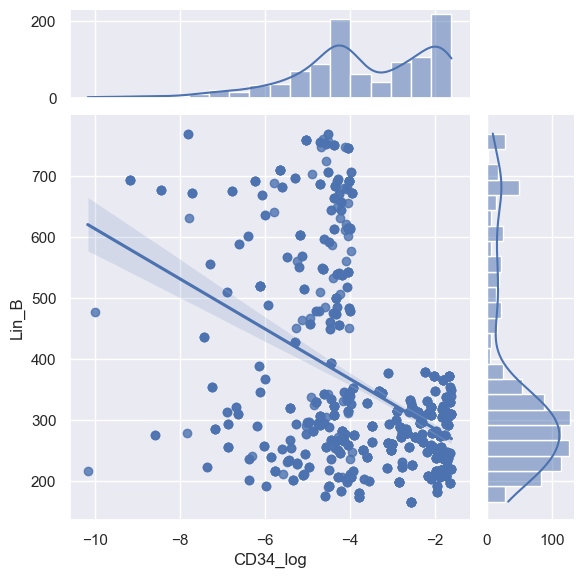

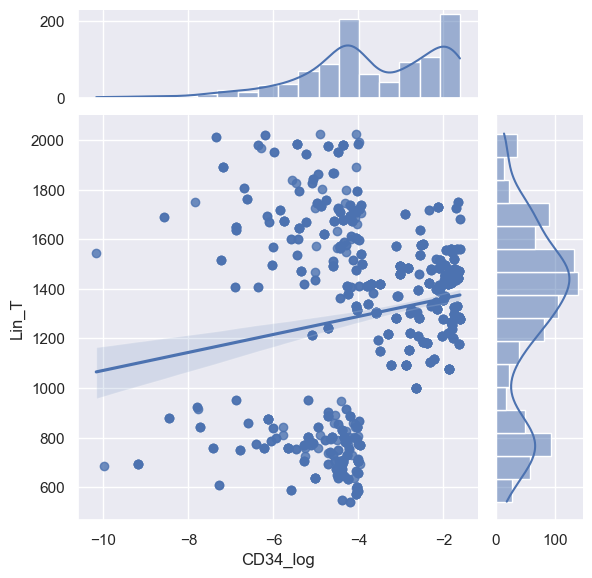

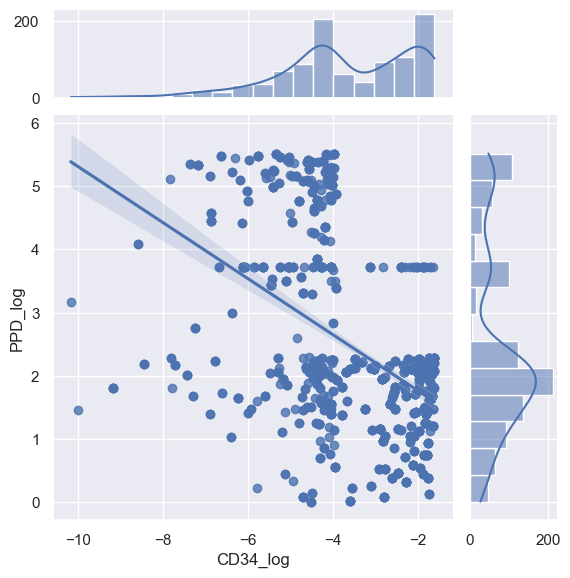

In [125]:
# Gráfico de correlação entre os dados
x = df_num_rel['CD34_log']
y1 = df_num_rel['Lin_B']
y2 = df_num_rel['Lin_T']
y3 = df_num_rel['PPD_log']

p = sns.jointplot(
    x=x,
    y=y1,
    kind="reg",
    height=6,
    ratio=4,
    #hue = "classe"
    marginal_ticks=True,
    data = df_num_rel
)
p.set_axis_labels(xlabel='CD34_log', ylabel='Lin_B')

q = sns.jointplot(
    x=x,
    y=y2,
    kind="reg",
    height=6,
    ratio=4,
    #hue = "classe"
    marginal_ticks=True,
    data = df_num_rel
)
q.set_axis_labels(xlabel='CD34_log', ylabel='Lin_T')

r = sns.jointplot(
    x=x,
    y=y3,
    kind="reg",
    height=6,
    ratio=4,
    #hue = "classe"
    marginal_ticks=True,
    data = df_num_rel
)
r.set_axis_labels(xlabel='CD34_log', ylabel='PPD_log')

# Show plot
plt.show()


Manterei essas variaveis numericas e categoricas

### Dataframe processado

In [136]:
df_processada = pd.concat([df_num_rel[['CD34_log','Lin_B', 'Lin_T', 'PPD_log' ]], df_projeto.select_dtypes('object')],axis=1)
df_processada

,CD34_log,Lin_B,Lin_T,PPD_log,FOXP3,classe,Igs,citoc
0,-2.125596,253.279174,1728.482473,0.588027,Normal,leucemia,Alto,Baixo
1,-2.185510,248.227101,1345.088460,3.714128,Normal,leucemia,Alto,Baixo
2,-1.739342,312.692349,1466.827903,2.057824,Normal,leucemia,Alto,Baixo
3,-2.544432,321.219514,1637.813475,2.230950,Normal,leucemia,Alto,Baixo
4,-2.795526,271.781339,1222.570768,0.083765,Normal,leucemia,Alto,Baixo
...,...,...,...,...,...,...,...,...
995,-1.789109,235.466548,1548.882842,0.756665,Normal,leucemia,Alto,Baixo
996,-4.588500,176.167332,1865.920678,5.410892,Normal,BCG,Alto,Alto
997,-3.011878,261.346361,1492.771234,2.160236,Normal,leucemia,Alto,Baixo
998,-6.869732,255.604372,1650.553716,4.441393,Normal,BCG,Alto,Alto


In [138]:
df_estruturada = dump(df_processada, './df_estruturada')

Aplico neste arquivo no script y_data_profiling_SofiaFeronato.ipynb, e ele nos retorna agora o relatorio dos dados estruturados para aplicação dos algoritmos


## Alterando categóricas para booleanas

In [141]:
desc_cat = df_processada.describe(include = 'object') #categorical and boolean

In [142]:
desc_cat

,FOXP3,classe,Igs,citoc
count,1000,1000,1000,1000
unique,2,4,2,2
top,Normal,cancer,Alto,Baixo
freq,760,269,760,736


In [145]:
# Convertendo variáveis categóricas em variáveis dummy - total 3 colunas
df_processada_cat = pd.get_dummies(df_processada, columns=['FOXP3', 'Igs', 'citoc'])

In [146]:
df_processada_cat

,CD34_log,Lin_B,Lin_T,PPD_log,classe,FOXP3_Alterado,FOXP3_Normal,Igs_Alto,Igs_Baixo,citoc_Alto,citoc_Baixo
0,-2.125596,253.279174,1728.482473,0.588027,leucemia,False,True,True,False,False,True
1,-2.185510,248.227101,1345.088460,3.714128,leucemia,False,True,True,False,False,True
2,-1.739342,312.692349,1466.827903,2.057824,leucemia,False,True,True,False,False,True
3,-2.544432,321.219514,1637.813475,2.230950,leucemia,False,True,True,False,False,True
4,-2.795526,271.781339,1222.570768,0.083765,leucemia,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
995,-1.789109,235.466548,1548.882842,0.756665,leucemia,False,True,True,False,False,True
996,-4.588500,176.167332,1865.920678,5.410892,BCG,False,True,True,False,True,False
997,-3.011878,261.346361,1492.771234,2.160236,leucemia,False,True,True,False,False,True
998,-6.869732,255.604372,1650.553716,4.441393,BCG,False,True,True,False,True,False


In [147]:
df_trabalho = dump(df_processada_cat, './df_trabalho')
df_trabalho

['./df_trabalho']

## Salvando datasets para treino, validação e teste

In [148]:
# Separação de dados em treino, validação e teste
from fast_ml.model_development import train_valid_test_split

In [149]:
X_train, y_train, X_valid, y_valid, X_test, y_test = train_valid_test_split(
    df_processada_cat,
    target="classe",
    train_size=0.7,
    valid_size=0.2,
    test_size=0.1,
    random_state=42,
)

print("-" * 10)
print(f"X_train: {X_train.shape}")
print(f"X_valid: {X_valid.shape}")
print(f"X_test: {X_test.shape}")
print("-" * 10)
print(f"y_train: {y_train.shape}")
print(f"y_valid: {y_valid.shape}")
print(f"y_test: {y_test.shape}")

----------
X_train: (700, 10)
X_valid: (200, 10)
X_test: (100, 10)
----------
y_train: (700,)
y_valid: (200,)
y_test: (100,)


In [150]:
dump(X_train, "./df_trabalho_X_train")
dump(X_valid, "./df_trabalho_X_valid")
dump(X_test, "./df_trabalho_X_test")

dump(y_train, "./df_trabalho_y_train")
dump(y_valid, "./df_trabalho_y_valid")
dump(y_test, "./df_trabalho_y_test")

df_X = load("./df_trabalho_X_train")
df_y = load("./df_trabalho_y_train")
df_X.head()

,CD34_log,Lin_B,Lin_T,PPD_log,FOXP3_Alterado,FOXP3_Normal,Igs_Alto,Igs_Baixo,citoc_Alto,citoc_Baixo
541,-6.605859,587.422573,861.125119,1.728509,True,False,False,True,False,True
440,-4.329437,500.185650,801.998581,1.240507,True,False,False,True,False,True
482,-1.748794,208.645029,1299.553614,1.470395,False,True,True,False,False,True
422,-4.197952,537.954188,889.391214,1.574182,True,False,False,True,False,True
778,-1.880539,274.394770,1419.982269,3.714128,False,True,True,False,False,True
